    
Будем работать с датасетом по видеоигре Dota 2.

Мы будем пытаться предсказать исход матча - победа или поражение. Целевая метрика - коэффициент Джини и ROC-AUC.

$$ \text{Gini} = | 2 \cdot \text{ROCAUC} - 1 |$$

In [1]:
from sklearn.metrics import roc_auc_score
from typing import Optional, Callable


def gini(y_true, y_score):
    return abs(2 * roc_auc_score(y_true, y_score) - 1.0)

#### **Данные**
1. Информация о матчах - `matches_df_train.csv`.
2. Информация об игроках - `player_df.csv`.
3. Информация о героях - `Constants.Heroes.csv`.
4. Информация о статистиках матча - `dota_adv.csv`.
5. Тестовые данные для соревнования - `matches_df_test.csv`.

Начнём с предобработки данных:
1. Посмотрим на все датафреймы выше - какие в них колонки, по какому признаку их можно джойнить между собой, на типы и тд;
2. Проверим, есть ли в данных пропуски, дубли, выбросы;
3. Разобьём данные на трейн и валидацию;
4. Построим график распределения целевой переменной на трейне и валидации.


In [2]:
import pandas as pd
matches = pd.read_csv('matches_df_train.csv')
player = pd.read_csv('player_df.csv')
heroes = pd.read_csv('Constants.Heroes.csv')
stat = pd.read_csv('dota_adv.csv')
matches_test = pd.read_csv('matches_df_test.csv')


In [3]:
d = [(matches,'matches'), (player,'player'), (heroes,'heroes'), (stat,'stat')]
for i in d:
    print(f'Колонки в {i[1]}: {i[0].columns}')
for i in d:
    print(f'Количество пропусков в {i[1]}: {i[0].isnull().sum().sum()}')
for i in d:
    print(f'Количество дубликатов в {i[1]}: {i[0].duplicated().sum()}')

Колонки в matches: Index(['match_id', 'date', 'region', 'game_mode', 'duration', 'radiant_win'], dtype='object')
Колонки в player: Index(['player_slot', 'account_id', 'hero_id', 'kills', 'deaths', 'assists',
       'gold', 'last_hits', 'denies', 'gold_per_min', 'xp_per_min',
       'hero_damage', 'tower_damage', 'match_id'],
      dtype='object')
Колонки в heroes: Index(['Unnamed: 0', 'id', 'name', 'primary_attr', 'attack_type', 'roles',
       'img', 'icon', 'base_health', 'base_health_regen', 'base_mana',
       'base_mana_regen', 'base_armor', 'base_mr', 'base_attack_min',
       'base_attack_max', 'base_str', 'base_agi', 'base_int', 'str_gain',
       'agi_gain', 'int_gain', 'attack_range', 'projectile_speed',
       'attack_rate', 'base_attack_time', 'attack_point', 'move_speed',
       'turn_rate', 'cm_enabled', 'legs', 'day_vision', 'night_vision',
       'localized_name'],
      dtype='object')
Колонки в stat: Index(['match_id', 'radiant_gold_adv', 'radiant_exp_adv'], dtype='ob

matches содержит match_id — уникальный идентификатор матча.

player — соддержит match_id, а также account_id.

advanced stats можно присоединять по match_id.

heroes — связывается по hero_id.

Text(0.5, 0, 'hero_damage')

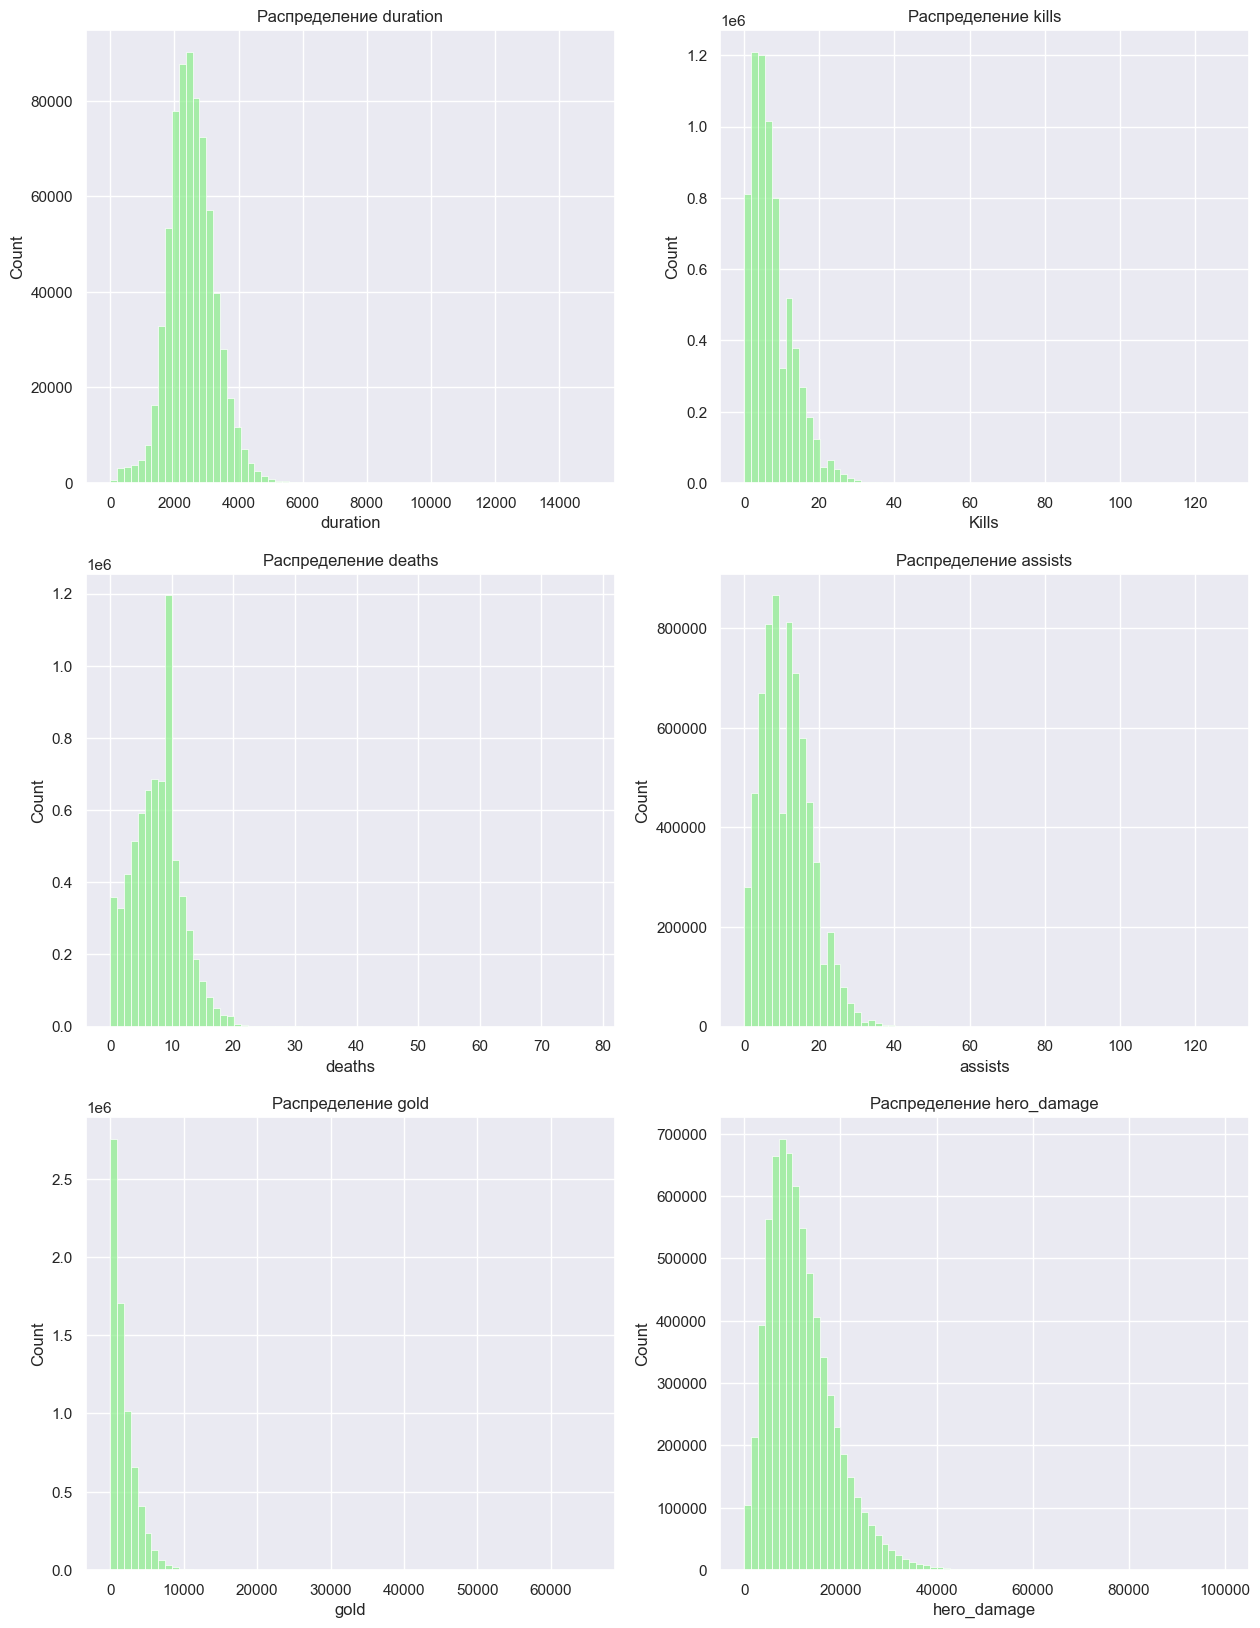

In [4]:
#Анализ выбросов
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
sns.set(style='darkgrid')
fig, ax = plt.subplots(3,2, figsize = (15,20))
sns.histplot(data = matches, bins = 70, x = 'duration',color = 'lightgreen', ax = ax[0,0])
ax[0,0].set_title('Распределение duration')
ax[0,0].set_xlabel('duration')
sns.histplot(data = player, bins = 70, x = 'kills', color = 'lightgreen', ax = ax[0,1])
ax[0,1].set_title('Распределение kills')
ax[0,1].set_xlabel('Kills')
sns.histplot(data = player, bins = 70, x = 'deaths', color = 'lightgreen', ax = ax[1,0])
ax[1,0].set_title('Распределение deaths')
ax[1,0].set_xlabel('deaths')
sns.histplot(data = player, bins = 70, x = 'assists', color = 'lightgreen', ax = ax[1,1])
ax[1,1].set_title('Распределение assists')
ax[1,1].set_xlabel('assists')
sns.histplot(data = player, bins = 70, x = 'gold', color = 'lightgreen', ax = ax[2,0])
ax[2,0].set_title('Распределение gold')
ax[2,0].set_xlabel('gold')
sns.histplot(data = player, bins = 70, x = 'hero_damage', color = 'lightgreen', ax = ax[2,1])
ax[2,1].set_title('Распределение hero_damage')
ax[2,1].set_xlabel('hero_damage')








Text(0.5, 1.0, 'radiant_win на тестовой выборке')

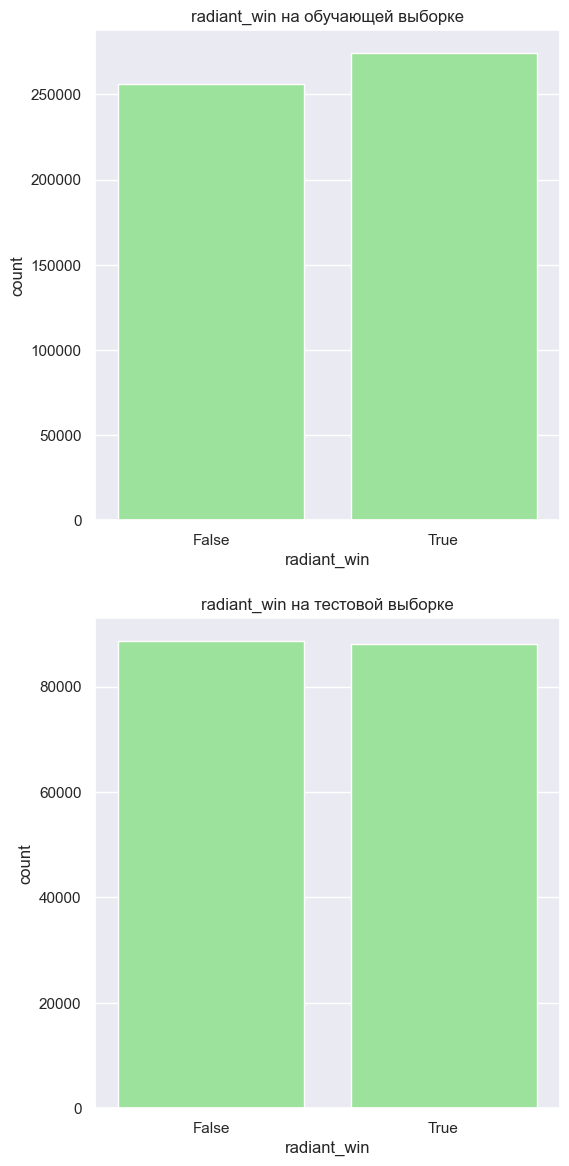

In [5]:
#Разбиение данных
matches.sort_values(by = 'date')
split_index= int(matches.shape[0] * 0.75)
matches_train = matches.iloc[:split_index].copy()
matches_val = matches.iloc[split_index:].copy()
fig, ax = plt.subplots(2, figsize = (6,14))
sns.countplot(data = matches_train, color = 'lightgreen', x = 'radiant_win', ax = ax[0])
ax[0].set_title('radiant_win на обучающей выборке')
sns.countplot(data = matches_val, color = 'lightgreen', x = 'radiant_win', ax = ax[1])
ax[1].set_title('radiant_win на тестовой выборке')











#### **Выбор признаков и построение модели**

Будем решать задачу классификации, воспользуемся логистической регрессией

#### Выбор признаков и объединение датасетов

1. Признаки на основе matches_df_train.csv и matches_df_test.csv
Это основной файл, который связывает все остальные.

Целевая переменная: radiant_win

Базовые идентификаторы: match_id, cluster (регион/кластер сервера).

Время: start_time (можно вытащить час дня, день недели, месяц — может влиять на активность игроков и, следовательно, на их уровень).

2. Признаки на основе player_df.csv (основной источник признаков)
Здесь информация по каждому игроку в каждом матче. Нужно агрегировать данные по командам (Radiant и Dire).

Для каждого игрока в матче:

hero_id -> Связь с таблицей героев. 
 
level -> Уровень героя на момент матча

kills, deaths, assists (K/D/A) -> Количество на момент матча.

gold -> Текущее золото.

gold_spent -> Потраченное золото.

xp -> Опыт.

last_hits, denies -> Количество добитых крипов и своих крипов, убитых для предотвращения получения опыта врагом.

gold_per_min, xp_per_min -> Золото и опыт в минуту (хорошие метрики эффективности).  

Агрегация (для каждой команды в каждом матче):

Суммы: total_kills, total_gold, total_xp, total_last_hits.

Средние значения: avg_level, avg_gold_per_min, avg_xp_per_min.

In [6]:
from sklearn.linear_model import LogisticRegression
matches = pd.read_csv('matches_df_train.csv')
matches.sort_values(by = 'date')
def team(row):
    return 'radiant' if row['player_slot'] < 128 else 'dire'
players_heroes = player.merge(heroes[['id', 'primary_attr', 'attack_type']], left_on = 'hero_id', right_on = 'id' , how = 'left')
players_heroes['team'] = players_heroes.apply(team, axis = 1)
new_features = players_heroes.groupby(['match_id', 'team']).agg({
    'kills': 'sum',
    'deaths': 'sum',
    'assists': 'sum',
    'gold_per_min': 'mean',
    'xp_per_min': 'mean',
    'hero_damage': 'sum',
    'tower_damage': 'sum'
}).reset_index()
new_features = new_features.pivot(index='match_id', columns='team')
new_features.columns = [f"{col[1]}_{col[0]}" for col in new_features.columns]
new_features = new_features.reset_index()
full_matches = matches.merge(new_features, on = 'match_id', how = 'left')
features = ['game_mode', 'duration', 'dire_kills', 'radiant_kills', 'dire_deaths', 'radiant_deaths', 'dire_assists', 'radiant_assists', 'dire_gold_per_min', 'radiant_gold_per_min',
'dire_xp_per_min', 'radiant_xp_per_min', 'dire_hero_damage', 'radiant_hero_damage', 'dire_tower_damage', 'radiant_tower_damage']
X = full_matches[features].fillna(0)
y = full_matches['radiant_win'].fillna(0)
split_index = int(full_matches.shape[0] * 0.75)
full_matches_train = full_matches.iloc[:split_index].copy()
full_matches_val = full_matches.iloc[split_index:].copy()
X_train = full_matches_train[features].fillna(0)
X_val = full_matches_val[features].fillna(0)
y_train = full_matches_train['radiant_win'].fillna(0)
y_val = full_matches_val['radiant_win'].fillna(0)
model = LogisticRegression(solver='liblinear')
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
y_proba = model.predict_proba(X_val)[:, 1]
print(roc_auc_score(y_val, y_proba))

0.9990494905680494


#### Optuna

Для эффективного подбора гиперпараметров воспользуемся библиотекой Optuna, которая упрощает перебор гиперпараметров, а также сохраняет всю историю экспериментов.

In [7]:
import optuna
def objective(trial):

    # гипепараметры модели
    model_params = {"C": trial.suggest_float("C", 1e-3, 10.0, log=True),
    "penalty": trial.suggest_categorical("penalty", ["l1", "l2"]),
     "solver": trial.suggest_categorical("solver", ["liblinear", "saga"])
    }
    model = LogisticRegression(**model_params)
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_val)[:, 1]
    gini_valid = gini(y_val, y_proba)
    return gini_valid



In [8]:
study_name = "logreg_optuna"


storage_name = f"sqlite:///{study_name}.db"


study = optuna.create_study(
    study_name=study_name,
    storage=storage_name,
    direction="maximize",
    load_if_exists=True
)


study.optimize(objective, n_trials=30, n_jobs=1)


print("Лучшие параметры:", study.best_params)
print("Лучшее значение Gini:", study.best_value)


[I 2026-07-08 23:01:02,950] Using an existing study with name 'logreg_optuna' instead of creating a new one.
[I 2026-07-08 23:01:15,638] Trial 500 finished with value: 0.9981363114204431 and parameters: {'C': 0.05491552973891606, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 500 with value: 0.9981363114204431.
[I 2026-07-08 23:01:26,503] Trial 501 finished with value: 0.9981358282916044 and parameters: {'C': 0.04843560278916502, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 500 with value: 0.9981363114204431.
[I 2026-07-08 23:01:37,563] Trial 502 finished with value: 0.9981363436973434 and parameters: {'C': 0.07442225289996601, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 502 with value: 0.9981363436973434.
[I 2026-07-08 23:01:50,157] Trial 503 finished with value: 0.9981365476053792 and parameters: {'C': 0.056758536580798505, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 503 with value: 0.9981365476053792.
[I 2026-07-08 23:02:01,290] Trial 504 fini

Лучшие параметры: {'C': 0.056758536580798505, 'penalty': 'l1', 'solver': 'liblinear'}
Лучшее значение Gini: 0.9981365476053792
